# Phần C — Phân tích, Mô hình, Insight (Chủ đề 12: AQI & bệnh hô hấp)

Câu hỏi nghiên cứu: sau khi tính đến tỷ lệ hút thuốc, county có AQI cao hơn có tỷ lệ COPD/Asthma cao hơn không, và mối liên hệ này mạnh cỡ nào?

Dữ liệu quan sát, không phải thí nghiệm -> chỉ nói được **liên hệ**, không nói được **nhân quả**.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt


## 1. Đọc dữ liệu và merge lại 3 bảng

Biến cần nằm ở 3 bảng khác nhau (AirQuality, RespiratoryDisease, Demographic), nối lại theo `CountyFIPS + Year` để có đủ trong 1 dòng.

In [2]:
location = pd.read_csv("Location.csv")
air_quality = pd.read_csv("AirQuality.csv")
respiratory_disease = pd.read_csv("RespiratoryDisease.csv")
demographic = pd.read_csv("Demographic.csv")

df = respiratory_disease.merge(air_quality, on=["CountyFIPS", "Year"])
df = df.merge(demographic, on=["CountyFIPS", "Year"])
df = df.merge(location, on="CountyFIPS")

print(df.shape)
df.head()


(6406, 37)


,CountyFIPS,Year,Disease,Disease_AdjPrev,is_extreme_disease,Days_with_AQI,Good_Days,Moderate_Days,USG_Days,Unhealthy_Days,...,Smoking_AdjPrev,Complete_4_Years,is_extreme_smoking,is_extreme_population,City,County,StateAbbr,State,Latitude,Longitude
0,1003,2019,COPD,6.9,False,271,221,50,0,0,...,19.9,True,False,False,Fairhope,Baldwin,AL,Alabama,30.693482,-87.73441
1,1003,2019,Current Asthma,8.9,False,271,221,50,0,0,...,19.9,True,False,False,Fairhope,Baldwin,AL,Alabama,30.693482,-87.73441
2,1003,2020,COPD,6.7,False,269,223,46,0,0,...,16.9,True,False,False,Fairhope,Baldwin,AL,Alabama,30.693482,-87.73441
3,1003,2020,Current Asthma,9.3,False,269,223,46,0,0,...,16.9,True,False,False,Fairhope,Baldwin,AL,Alabama,30.693482,-87.73441
4,1003,2021,COPD,6.5,False,280,248,32,0,0,...,15.0,True,False,False,Fairhope,Baldwin,AL,Alabama,30.693482,-87.73441


In [3]:
print("Số dòng RespiratoryDisease gốc:", len(respiratory_disease))
print("Số dòng sau merge:", len(df))
print("Missing theo cột chính:")
print(df[["Median_AQI", "Disease_AdjPrev", "Smoking_AdjPrev"]].isna().sum())


Số dòng RespiratoryDisease gốc: 6406
Số dòng sau merge: 6406
Missing theo cột chính:
Median_AQI         0
Disease_AdjPrev    0
Smoking_AdjPrev    0
dtype: int64


Nếu 2 số dòng ở trên không khớp nhau, dừng lại kiểm tra merge trước khi đi tiếp — khả năng cao là trùng hoặc thiếu key ở 1 trong 3 bảng.

## 2. Tách riêng COPD và Asthma

Không pivot gộp 2 bệnh thành 2 cột vì COPD và Asthma có hành vi khác nhau theo thời gian (COPD gần như không đổi theo năm trong 1 county, Asthma đổi nhiều hơn) — gộp chung sẽ mất đi khác biệt này.

In [4]:
df_copd = df[df["Disease"] == "COPD"].copy()
df_asthma = df[df["Disease"] == "Current Asthma"].copy()

print("COPD:", df_copd.shape)
print("Asthma:", df_asthma.shape)

print(df_copd[["Median_AQI", "Disease_AdjPrev", "Smoking_AdjPrev"]].describe())
print(df_copd[["Median_AQI", "Disease_AdjPrev", "Smoking_AdjPrev"]].corr())


COPD: (3203, 37)
Asthma: (3203, 37)
        Median_AQI  Disease_AdjPrev  Smoking_AdjPrev
count  3203.000000      3203.000000      3203.000000
mean     40.449891         6.401686        16.685357
std       9.622719         1.408404         3.909609
min       1.000000         3.300000         6.500000
25%      36.000000         5.400000        13.900000
50%      41.000000         6.300000        16.500000
75%      46.000000         7.300000        19.300000
max     122.000000        15.000000        34.900000
                 Median_AQI  Disease_AdjPrev  Smoking_AdjPrev
Median_AQI         1.000000        -0.074787        -0.134778
Disease_AdjPrev   -0.074787         1.000000         0.878346
Smoking_AdjPrev   -0.134778         0.878346         1.000000


Nhìn `.corr()` giữa `Median_AQI` và `Smoking_AdjPrev` — nếu trên 0.8, hai biến quá giống nhau, mô hình sẽ khó tách được đóng góp riêng của từng biến (đa cộng tuyến). Dưới mức đó thì chạy tiếp bình thường.

## 3. Fit mô hình OLS

Y là tỷ lệ phần trăm liên tục (`Disease_AdjPrev`) nên dùng Linear Regression, không dùng Logistic (Logistic chỉ hợp với Y nhị phân).

Thêm `C(Year)` để so sánh các county trong cùng 1 năm, tránh nhầm xu hướng chung của cả nước theo năm thành liên hệ AQI-bệnh.

Dùng `cov_type="cluster"` theo `CountyFIPS` vì mỗi county lặp lại 4 lần (4 năm) và bệnh gần như không đổi giữa các năm đó — 4 dòng này không thực sự độc lập, cluster SE sửa lại p-value cho đúng.

In [5]:
model_copd = smf.ols(
    "Disease_AdjPrev ~ Median_AQI + Smoking_AdjPrev + C(Year)",
    data=df_copd
).fit(cov_type="cluster", cov_kwds={"groups": df_copd["CountyFIPS"]})

print(model_copd.summary())


                            OLS Regression Results                            
Dep. Variable:        Disease_AdjPrev   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     799.7
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:49:22   Log-Likelihood:                -2724.1
No. Observations:                3203   AIC:                             5460.
Df Residuals:                    3197   BIC:                             5497.
Df Model:                           5                                         
Covariance Type:              cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.1783      0.124     

In [6]:
model_asthma = smf.ols(
    "Disease_AdjPrev ~ Median_AQI + Smoking_AdjPrev + C(Year)",
    data=df_asthma
).fit(cov_type="cluster", cov_kwds={"groups": df_asthma["CountyFIPS"]})

print(model_asthma.summary())


                            OLS Regression Results                            
Dep. Variable:        Disease_AdjPrev   R-squared:                       0.390
Model:                            OLS   Adj. R-squared:                  0.389
Method:                 Least Squares   F-statistic:                     619.3
Date:                Sat, 26 Sep 2026   Prob (F-statistic):          1.36e-281
Time:                        11:49:22   Log-Likelihood:                -3723.4
No. Observations:                3203   AIC:                             7459.
Df Residuals:                    3197   BIC:                             7495.
Df Model:                           5                                         
Covariance Type:              cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           7.3229      0.170     

Đọc kết quả: nhìn `coef` của `Median_AQI` (dương = AQI cao đi cùng bệnh cao hơn), `P>|z|` (dưới 0.05 mới coi là có ý nghĩa thống kê), và `R-squared` (thấp, kiểu 0.1-0.3, là bình thường với dữ liệu quan sát, không phải mô hình sai).

## 4. Kiểm tra độ ổn định (Cook's Distance)

Kiểm tra xem kết quả có bị vài county lạ kéo lệch hay không, trước khi tin vào hệ số ở trên.

In [7]:
def kiem_tra_on_dinh(model, data, formula):
    influence = model.get_influence()
    cooks_d = influence.cooks_distance[0]
    threshold = 4 / len(data)

    data_robust = data[cooks_d <= threshold]
    model_robust = smf.ols(formula, data=data_robust).fit(
        cov_type="cluster", cov_kwds={"groups": data_robust["CountyFIPS"]}
    )

    print("Số điểm bị đánh dấu ảnh hưởng mạnh:", (cooks_d > threshold).sum(), "/", len(data))
    print("Hệ số AQI (đầy đủ):", round(model.params["Median_AQI"], 4))
    print("Hệ số AQI (bỏ điểm ảnh hưởng):", round(model_robust.params["Median_AQI"], 4))
    return model_robust


formula = "Disease_AdjPrev ~ Median_AQI + Smoking_AdjPrev + C(Year)"

print("--- COPD ---")
model_copd_robust = kiem_tra_on_dinh(model_copd, df_copd, formula)

print("--- Asthma ---")
model_asthma_robust = kiem_tra_on_dinh(model_asthma, df_asthma, formula)


--- COPD ---
Số điểm bị đánh dấu ảnh hưởng mạnh: 179 / 3203
Hệ số AQI (đầy đủ): 0.0078
Hệ số AQI (bỏ điểm ảnh hưởng): 0.0055
--- Asthma ---
Số điểm bị đánh dấu ảnh hưởng mạnh: 149 / 3203
Hệ số AQI (đầy đủ): -0.0032
Hệ số AQI (bỏ điểm ảnh hưởng): -0.0052


Nếu 2 hệ số (đầy đủ vs bỏ điểm ảnh hưởng) gần nhau -> ghi vào báo cáo "mô hình ổn định, không bị chi phối bởi vài điểm cực trị". Nếu lệch nhiều, nêu thẳng cả 2 con số, không được giấu bớt.

## 5. Bảng dự báo để bàn giao cho Dashboard (B)

Rubric yêu cầu đường dự báo nằm trên Dashboard, không phải notebook riêng — chỉ cần tính sẵn bảng rồi xuất CSV cho B vẽ.

In [8]:
def bang_du_bao(model, data, ten_benh):
    aqi_range = np.linspace(data["Median_AQI"].min(), data["Median_AQI"].max(), 50)
    nam_pho_bien = data["Year"].mode()[0]

    input_du_bao = pd.DataFrame({
        "Median_AQI": aqi_range,
        "Smoking_AdjPrev": data["Smoking_AdjPrev"].mean(),
        "Year": nam_pho_bien
    })

    ket_qua = model.get_prediction(input_du_bao).summary_frame(alpha=0.05)
    ket_qua["Median_AQI"] = aqi_range
    ket_qua["Disease"] = ten_benh

    return ket_qua[["Disease", "Median_AQI", "mean", "mean_ci_lower", "mean_ci_upper"]]


du_bao_copd = bang_du_bao(model_copd, df_copd, "COPD")
du_bao_asthma = bang_du_bao(model_asthma, df_asthma, "Current Asthma")

du_bao = pd.concat([du_bao_copd, du_bao_asthma], ignore_index=True)
du_bao.to_csv("du_bao_aqi_benh.csv", index=False)
du_bao.head()


,Disease,Median_AQI,mean,mean_ci_lower,mean_ci_upper
0,COPD,1.000000,5.793682,5.661624,5.925741
1,COPD,3.469388,5.813030,5.688202,5.937859
2,COPD,5.938776,5.832378,5.714720,5.950036
3,COPD,8.408163,5.851726,5.741167,5.962285
4,COPD,10.877551,5.871074,5.767527,5.974620


## 6. Bảng tổng hợp hệ số cho báo cáo (mục 5)

In [9]:
def tom_tat_mo_hinh(model, ten_benh):
    return pd.DataFrame({
        "Disease": ten_benh,
        "Bien": model.params.index,
        "He_so": model.params.values,
        "P_value": model.pvalues.values,
        "R2": model.rsquared
    })


tom_tat = pd.concat([
    tom_tat_mo_hinh(model_copd, "COPD"),
    tom_tat_mo_hinh(model_asthma, "Current Asthma")
], ignore_index=True)

tom_tat = tom_tat[tom_tat["Bien"].isin(["Intercept", "Median_AQI", "Smoking_AdjPrev"])]
tom_tat.to_csv("tong_hop_he_so_mo_hinh.csv", index=False)
tom_tat


,Disease,Bien,He_so,P_value,R2
0,COPD,Intercept,-0.178294,1.516487e-01,0.838217
4,COPD,Median_AQI,0.007835,8.465064e-07,0.838217
5,COPD,Smoking_AdjPrev,0.356601,0.000000e+00,0.838217
6,Current Asthma,Intercept,7.322884,0.000000e+00,0.389814
10,Current Asthma,Median_AQI,-0.003238,1.878005e-01,0.389814
11,Current Asthma,Smoking_AdjPrev,0.133621,1.209287e-88,0.389814


## 7. Vẽ nhanh để tự kiểm tra trực quan (không bắt buộc nộp, chỉ để tự nhìn trước khi viết insight)

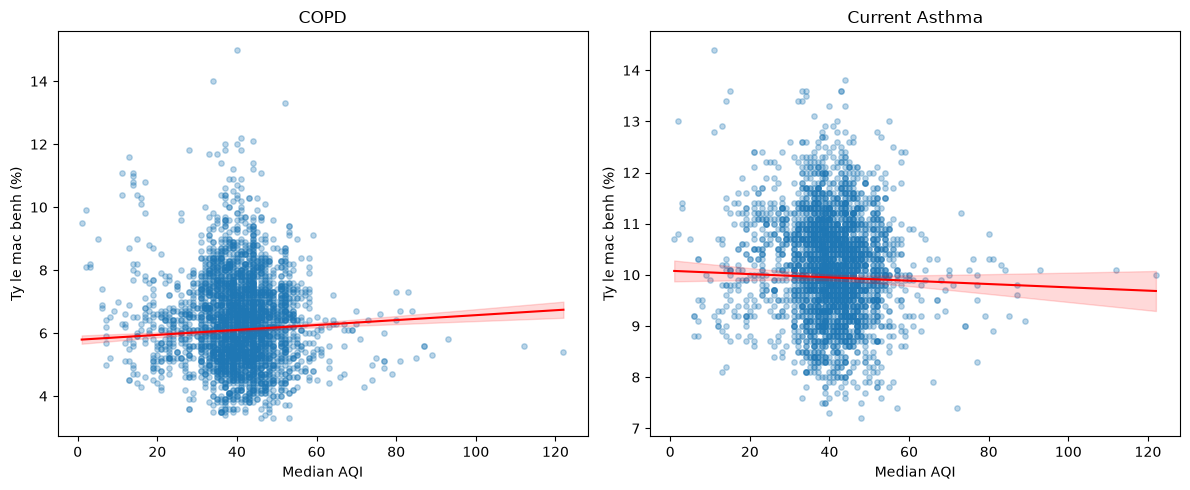

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, model, ten_benh in zip(
    axes,
    [df_copd, df_asthma],
    [model_copd, model_asthma],
    ["COPD", "Current Asthma"]
):
    ax.scatter(data["Median_AQI"], data["Disease_AdjPrev"], alpha=0.3, s=15)
    du_bao_benh = du_bao[du_bao["Disease"] == ten_benh]
    ax.plot(du_bao_benh["Median_AQI"], du_bao_benh["mean"], color="red")
    ax.fill_between(
        du_bao_benh["Median_AQI"],
        du_bao_benh["mean_ci_lower"],
        du_bao_benh["mean_ci_upper"],
        color="red", alpha=0.15
    )
    ax.set_title(ten_benh)
    ax.set_xlabel("Median AQI")
    ax.set_ylabel("Ty le mac benh (%)")

plt.tight_layout()
plt.savefig("kiem_tra_truc_quan.png", dpi=150)
plt.show()


## 8. Ghi lại số liệu để viết Insight (mục 4 báo cáo)

Nhìn `tong_hop_he_so_mo_hinh.csv` và điền vào mẫu câu:

> "Sau khi kiểm soát tỷ lệ hút thuốc và hiệu ứng năm, mỗi đơn vị AQI tăng thêm đi cùng [điền hệ số] điểm % tỷ lệ [COPD/Asthma] (p=[điền p-value]). Mô hình giải thích được [điền R²*100]% sự khác biệt về tỷ lệ bệnh giữa các county. Đây là liên hệ quan sát được, dữ liệu không đủ để kết luận AQI là nguyên nhân trực tiếp gây bệnh."

Đừng quên thêm phần Limitations: dữ liệu quan sát không phải thí nghiệm, PLACES là ước lượng mô hình không phải đếm ca trực tiếp, chỉ có county có trạm đo AQI, chỉ 4 năm (2019-2022), còn nhiều yếu tố chưa kiểm soát được (thu nhập, tiếp cận y tế, phơi nhiễm nghề nghiệp).